In [4]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Thiết lập hiển thị đồ thị
sns.set_theme(style="whitegrid")


# PHẦN 1: DATA CLEANSING & FEATURE ENGINEERING
print("--- Bước 1: Load dữ liệu ---")


# 1. Viết hàm load_data() để tải dữ liệu lên ứng dụng. Hiển thị 10 dòng đầu tiên.
def load_data():
    # Đọc file dữ liệu chung do người dùng cung cấp
    df = pd.read_csv("titanic_disaster.csv")
    return df


df_all = load_data()
print("10 dòng đầu tiên của tập dữ liệu:")
print(df_all.head(10))

print("\n--- Bước 2: Thống kê dữ liệu thiếu và trực quan hóa ---")


--- Bước 1: Load dữ liệu ---
10 dòng đầu tiên của tập dữ liệu:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   
5            6         0       3   
6            7         0       1   
7            8         0       3   
8            9         1       3   
9           10         1       2   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   
5                                   Moran, Mr. James    male   NaN      0   
6

Số lượng giá trị thiếu trên các biến:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


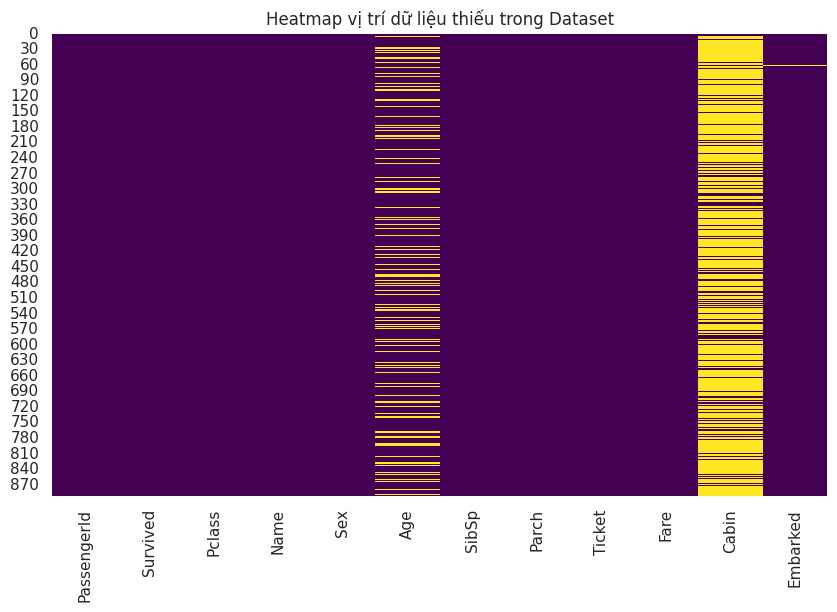

> Nhận xét về tình trạng thiếu dữ liệu:
  - Cabin: Thiếu cực kỳ nghiêm trọng (>70%), rất khó để điền khuyết chính xác.
  - Age: Thiếu khoảng 20%, phân bố rải rác, có thể điền khuyết dựa theo nhóm.
  - Embarked: Chỉ thiếu một vài vị trí nhỏ (2 dòng), xử lý dễ dàng bằng giá trị xuất hiện nhiều nhất (Mode).

--- Bước 3: Xử lý cột Name ---


In [5]:
# 2. Thống kê dữ liệu thiếu trên các biến số và trực quan hóa bằng biểu đồ Heatmap.
print("Số lượng giá trị thiếu trên các biến:")
print(df_all.isnull().sum())

plt.figure(figsize=(10, 6))
sns.heatmap(df_all.isnull(), cbar=False, cmap="viridis")
plt.title("Heatmap vị trí dữ liệu thiếu trong Dataset")
plt.show()

print(
    "> Nhận xét về tình trạng thiếu dữ liệu:\n"
    "  - Cabin: Thiếu cực kỳ nghiêm trọng (>70%), rất khó để điền khuyết chính xác.\n"
    "  - Age: Thiếu khoảng 20%, phân bố rải rác, có thể điền khuyết dựa theo nhóm.\n"
    "  - Embarked: Chỉ thiếu một vài vị trí nhỏ (2 dòng), xử lý dễ dàng bằng giá trị xuất hiện nhiều nhất (Mode)."
)

print("\n--- Bước 3: Xử lý cột Name ---")


In [6]:

# 3. Xử lý tên cột Name, tách ra làm 2 cột: firstName và secondName. Xóa luôn cột Name.
# Cấu trúc: "Braund, Mr. Owen Harris" -> Họ (firstName), Tên & Danh xưng (secondName)
df_all[["firstName", "secondName"]] = df_all["Name"].str.split(", ", n=1, expand=True)
df_all.drop(columns=["Name"], inplace=True)
print(df_all[["firstName", "secondName"]].head())

print("\n--- Bước 4: Xử lý rút gọn kích thước dữ liệu trên cột Sex ---")


   firstName                                  secondName
0     Braund                             Mr. Owen Harris
1    Cumings  Mrs. John Bradley (Florence Briggs Thayer)
2  Heikkinen                                 Miss. Laina
3   Futrelle          Mrs. Jacques Heath (Lily May Peel)
4      Allen                           Mr. William Henry

--- Bước 4: Xử lý rút gọn kích thước dữ liệu trên cột Sex ---


In [7]:
# 4. Thay thế male -> M và female -> F
gender_map = {"male": "M", "female": "F"}
df_all["Sex"] = df_all["Sex"].map(gender_map)
print(df_all["Sex"].value_counts())

print("\n--- Bước 5: Xử lý dữ liệu thiếu trên biến Age ---")


Sex
M    577
F    314
Name: count, dtype: int64

--- Bước 5: Xử lý dữ liệu thiếu trên biến Age ---


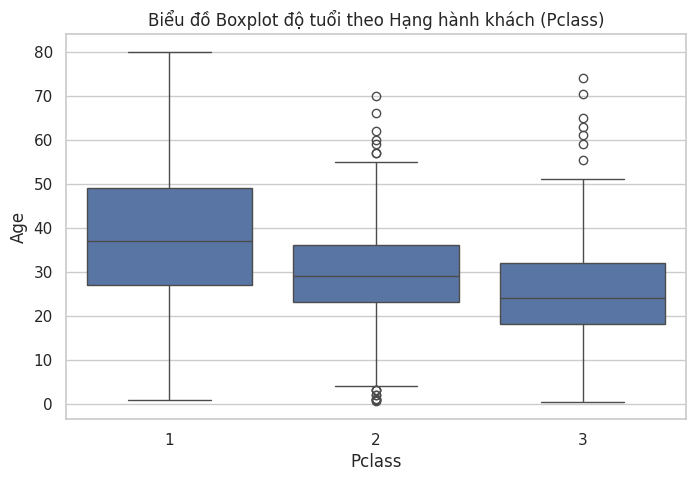

> Nhận xét Boxplot: Hạng ghế cao cấp (Pclass 1) có độ tuổi trung vị cao vượt trội,
  giảm dần ở Pclass 2 và thấp nhất ở Pclass 3. Vì vậy, ta quyết định dùng tuổi trung bình
  của từng nhóm Pclass để điền vào các vị trí trống của nhóm đó nhằm tăng độ chính xác.

Tuổi trung bình theo từng hạng hành khách (Pclass):
Pclass
1    38.233441
2    29.877630
3    25.140620
Name: Age, dtype: float64


/tmp/ipykernel_810/2618711920.py:21: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  Age = cols[0]
/tmp/ipykernel_810/2618711920.py:22: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  Pclass = cols[1]


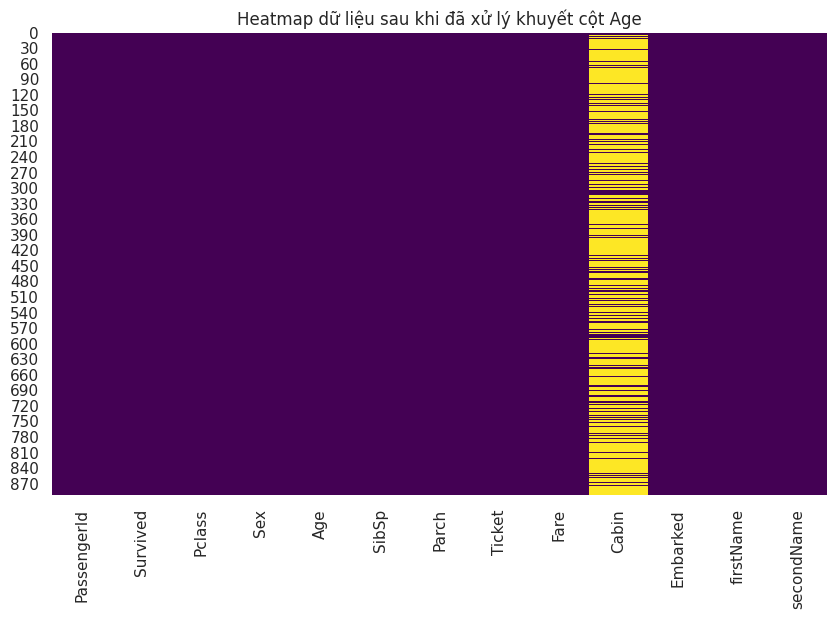


--- Bước 6: Xây dựng biến số Agegroup ---


In [8]:
# 5a. Sử dụng Seaborn để vẽ biểu đồ Box plot trực quan dữ liệu theo từng hạng hành khách (Pclass)
plt.figure(figsize=(8, 5))
sns.boxplot(x="Pclass", y="Age", data=df_all)
plt.title("Biểu đồ Boxplot độ tuổi theo Hạng hành khách (Pclass)")
plt.show()

print(
    "> Nhận xét Boxplot: Hạng ghế cao cấp (Pclass 1) có độ tuổi trung vị cao vượt trội,\n"
    "  giảm dần ở Pclass 2 và thấp nhất ở Pclass 3. Vì vậy, ta quyết định dùng tuổi trung bình\n"
    "  của từng nhóm Pclass để điền vào các vị trí trống của nhóm đó nhằm tăng độ chính xác."
)

# Tính tuổi trung bình theo từng Pclass để điền khuyết
age_means = df_all.groupby("Pclass")["Age"].mean()
print("\nTuổi trung bình theo từng hạng hành khách (Pclass):")
print(age_means)


# 5b. Tiến hành thay thế giá trị Age bị thiếu. Sau đó trực quan lại bằng biểu đồ Heatmap.
def impute_age(cols):
    Age = cols[0]
    Pclass = cols[1]
    if pd.isnull(Age):
        return age_means[Pclass]
    else:
        return Age


df_all["Age"] = df_all[["Age", "Pclass"]].apply(impute_age, axis=1)

# Trực quan lại dữ liệu sau khi xử lý thiếu cột Age
plt.figure(figsize=(10, 6))
sns.heatmap(df_all.isnull(), cbar=False, cmap="viridis")
plt.title("Heatmap dữ liệu sau khi đã xử lý khuyết cột Age")
plt.show()

print("\n--- Bước 6: Xây dựng biến số Agegroup ---")


In [9]:
# 6. (age <= 12) -> Kid; (12, 18]: Teen; (18, 60]: Adult; (age > 60): Older
def assign_age_group(age):
    if age <= 12:
        return "Kid"
    elif age <= 18:
        return "Teen"
    elif age <= 60:
        return "Adult"
    else:
        return "Older"


df_all["Agegroup"] = df_all["Age"].apply(assign_age_group)
print(df_all["Agegroup"].value_counts())

print("\n--- Bước 7: Thêm đặc trưng về danh xưng (namePrefix) ---")




Agegroup
Adult    730
Teen      70
Kid       69
Older     22
Name: count, dtype: int64

--- Bước 7: Thêm đặc trưng về danh xưng (namePrefix) ---


In [10]:
# 7. Tách Mr, Mrs, Miss, Master ra khỏi "secondName"
def extract_prefix(name):
    for prefix in ["Mr.", "Mrs.", "Miss.", "Master."]:
        if prefix in name:
            return prefix.replace(".", "")
    return "Unknown"


df_all["namePrefix"] = df_all["secondName"].apply(extract_prefix)
print(df_all["namePrefix"].value_counts())

print("\n--- Bước 8: Khai thác thông tin số lượng thành viên đi cùng ---")



namePrefix
Mr         517
Miss       182
Mrs        125
Master      40
Unknown     27
Name: count, dtype: int64

--- Bước 8: Khai thác thông tin số lượng thành viên đi cùng ---


In [11]:
# 8. familySize = 1 + SibSp + Parch
df_all["familySize"] = 1 + df_all["SibSp"] + df_all["Parch"]
print(df_all["familySize"].head())

print("\n--- Bước 9: Tạo thêm đặc trưng 'Alone' ---")



0    2
1    2
2    1
3    2
4    1
Name: familySize, dtype: int64

--- Bước 9: Tạo thêm đặc trưng 'Alone' ---


In [12]:
# 9. Nếu familySize = 1 thì Alone = 1, ngược lại là 0
df_all["Alone"] = np.where(df_all["familySize"] == 1, 1, 0)
print(df_all["Alone"].value_counts())

print("\n--- Bước 10: Tiến hành tách loại cabin (typeCabin) ---")


Alone
1    537
0    354
Name: count, dtype: int64

--- Bước 10: Tiến hành tách loại cabin (typeCabin) ---


In [13]:
# 10. Lấy ký tự đầu tiên của Cabin. Nếu thiếu (NaN) thì thay bằng "Unknown"
df_all["Cabin"] = df_all["Cabin"].fillna("Unknown")
df_all["typeCabin"] = df_all["Cabin"].apply(
    lambda x: x[0] if x != "Unknown" else "Unknown"
)
print(df_all["typeCabin"].value_counts())

print("\n--- Bước 11: Phân tách dữ liệu tránh trùng thừa ---")


typeCabin
Unknown    687
C           59
B           47
D           33
E           32
A           15
F           13
G            4
T            1
Name: count, dtype: int64

--- Bước 11: Phân tách dữ liệu tránh trùng thừa ---


In [14]:
# 11. Do dữ liệu được gộp chung, ta tiến hành tách thành tập huấn luyện (train) và đánh giá (test)
# theo cấu trúc tiêu chuẩn: 891 dòng đầu là tập train (có nhãn sống sót thực tế).
train_df = df_all.iloc[:891].copy()
test_df = df_all.iloc[891:].copy()

print(f"Kích thước tập huấn luyện (Train): {train_df.shape}")
print(f"Kích thước tập kiểm thử (Test): {test_df.shape}")

Kích thước tập huấn luyện (Train): (891, 18)
Kích thước tập kiểm thử (Test): (0, 18)



PHẦN 2: TRỰC QUAN HÓA DỮ LIỆU ĐỂ RÚT TRÍCH THÔNG TIN (EDA)


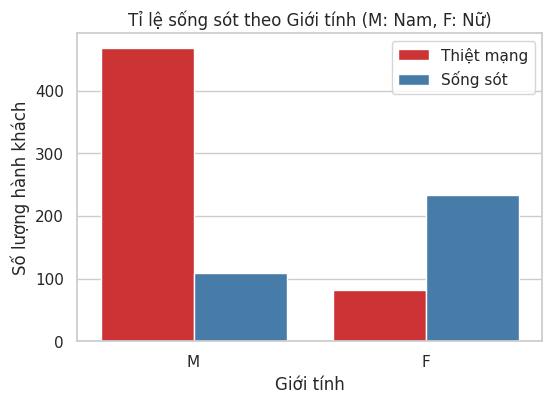

> Nhận xét 12: Phụ nữ (F) có tỷ lệ sống sót áp đảo so với Nam giới (M). Giới tính là đặc trưng cực kỳ quan trọng.


In [15]:
# PHẦN 2: KHAI THÁC THÔNG TIN HỮU ÍCH – EDA
print("\n" + "=" * 50)
print("PHẦN 2: TRỰC QUAN HÓA DỮ LIỆU ĐỂ RÚT TRÍCH THÔNG TIN (EDA)")
print("=" * 50)

# Điền khuyết nhẹ cho cột Embarked ở tập train để không ảnh hưởng đồ thị
train_df["Embarked"] = train_df["Embarked"].fillna(train_df["Embarked"].mode()[0])

# 12. Tương quan tỉ lệ sống sót và thiệt mạng trên từng nhóm giới tính
plt.figure(figsize=(6, 4))
sns.countplot(x="Sex", hue="Survived", data=train_df, palette="Set1")
plt.title("Tỉ lệ sống sót theo Giới tính (M: Nam, F: Nữ)")
plt.xlabel("Giới tính")
plt.ylabel("Số lượng hành khách")
plt.legend(["Thiệt mạng", "Sống sót"])
plt.show()
print(
    "> Nhận xét 12: Phụ nữ (F) có tỷ lệ sống sót áp đảo so với Nam giới (M). Giới tính là đặc trưng cực kỳ quan trọng."
)



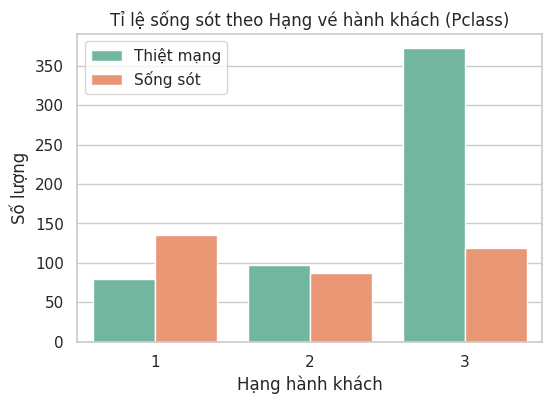

> Nhận xét 13: Hành khách thuộc Pclass 1 có cơ hội sống sót cao nhất. Ngược lại, hành khách mua vé hạng thấp (Pclass 3) gánh chịu tỷ lệ thiệt mạng lớn nhất.


In [16]:
# 13. Hành khách sống sót trên từng nhóm phân loại hành khách (Pclass)
plt.figure(figsize=(6, 4))
sns.countplot(x="Pclass", hue="Survived", data=train_df, palette="Set2")
plt.title("Tỉ lệ sống sót theo Hạng vé hành khách (Pclass)")
plt.xlabel("Hạng hành khách")
plt.ylabel("Số lượng")
plt.legend(["Thiệt mạng", "Sống sót"])
plt.show()
print(
    "> Nhận xét 13: Hành khách thuộc Pclass 1 có cơ hội sống sót cao nhất. Ngược lại, hành khách mua vé hạng thấp (Pclass 3) gánh chịu tỷ lệ thiệt mạng lớn nhất."
)



<Figure size 1000x500 with 0 Axes>

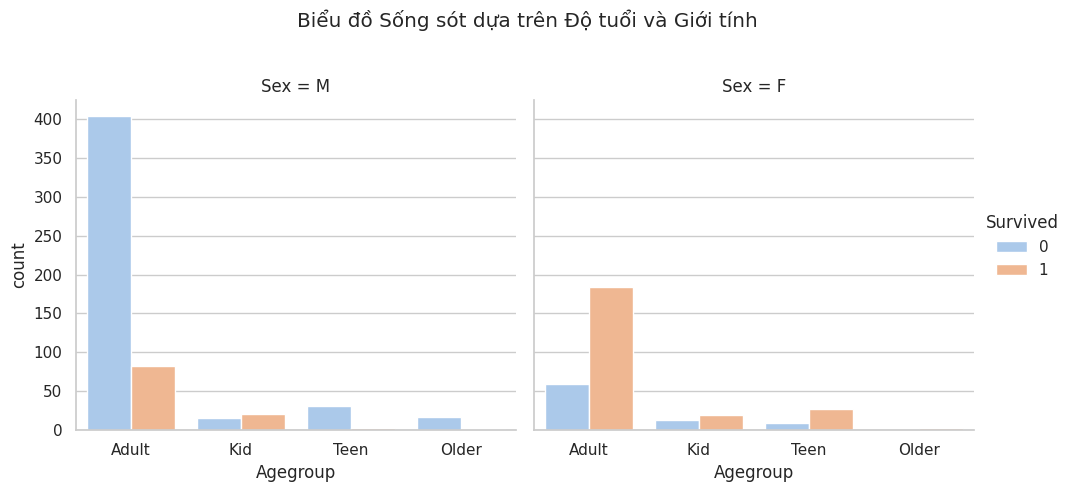

> Nhận xét 14: Nhóm trẻ em (Kid) ở cả hai giới đều được ưu tiên sống sót cao. Đàn ông ở độ tuổi trưởng thành (Adult) có số lượng thiệt mạng nhiều nhất trên tàu.


In [17]:
# 14. Hành khách sống sót trên từng nhóm giới tính và thang đo tuổi tác
plt.figure(figsize=(10, 5))
sns.catplot(
    x="Agegroup",
    hue="Survived",
    col="Sex",
    data=train_df,
    kind="count",
    palette="pastel",
)
plt.subplots_adjust(top=0.8)
plt.suptitle("Biểu đồ Sống sót dựa trên Độ tuổi và Giới tính")
plt.show()
print(
    "> Nhận xét 14: Nhóm trẻ em (Kid) ở cả hai giới đều được ưu tiên sống sót cao. Đàn ông ở độ tuổi trưởng thành (Adult) có số lượng thiệt mạng nhiều nhất trên tàu."
)



/tmp/ipykernel_810/2389135570.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x="familySize", y="Survived", data=train_df, ax=axes[0], ci=None)
/tmp/ipykernel_810/2389135570.py:6: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x="Alone", y="Survived", data=train_df, ax=axes[1], ci=None)


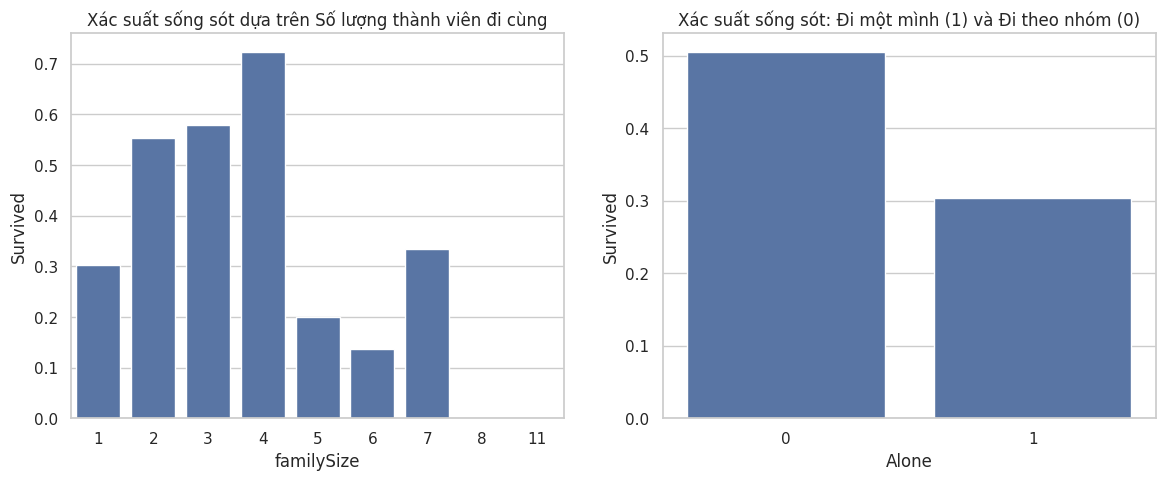

> Nhận xét 15: Đi một mình hoặc đi với gia đình quá đông (>4 người) làm giảm đáng kể khả năng sống sót. Đi theo nhóm gia đình nhỏ (2-4 người) đem lại cơ hội sống cao nhất.


In [18]:
# 15. Xác suất hành khách sống sót dựa trên thông tin nhóm đi cùng (familySize & Alone)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(x="familySize", y="Survived", data=train_df, ax=axes[0], ci=None)
axes[0].set_title("Xác suất sống sót dựa trên Số lượng thành viên đi cùng")

sns.barplot(x="Alone", y="Survived", data=train_df, ax=axes[1], ci=None)
axes[1].set_title("Xác suất sống sót: Đi một mình (1) và Đi theo nhóm (0)")
plt.show()
print(
    "> Nhận xét 15: Đi một mình hoặc đi với gia đình quá đông (>4 người) làm giảm đáng kể khả năng sống sót. Đi theo nhóm gia đình nhỏ (2-4 người) đem lại cơ hội sống cao nhất."
)



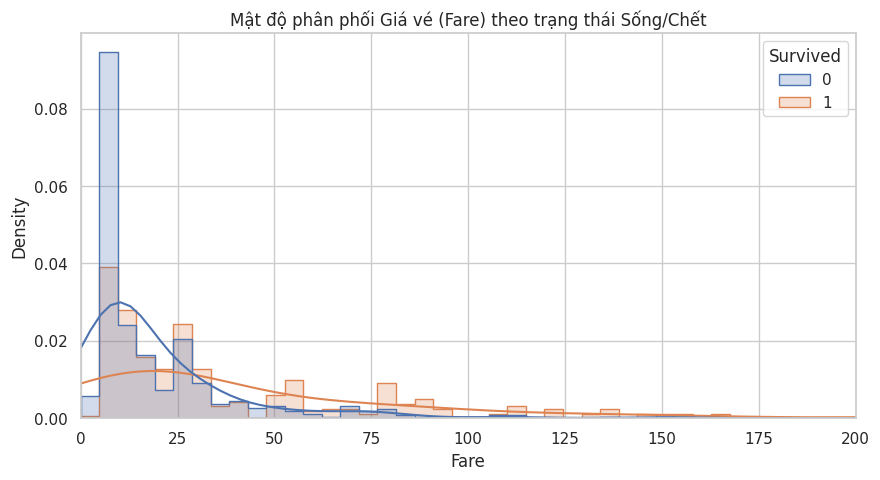

> Nhận xét 16: Mật độ thiệt mạng tập trung cực kỳ dày đặc ở nhóm vé giá rất rẻ (dưới 20$). Những hành khách chi trả chi phí cao hơn có phân phối xác suất sống sót vượt trội.


In [19]:
# 16. Xác suất hành khách sống sót dựa trên thông tin giá vé (Fare)
plt.figure(figsize=(10, 5))
sns.histplot(
    data=train_df,
    x="Fare",
    hue="Survived",
    element="step",
    stat="density",
    common_norm=False,
    kde=True,
)
plt.xlim(0, 200)  # Giới hạn phân phối vé phổ thông để biểu đồ trực quan, dễ quan sát
plt.title("Mật độ phân phối Giá vé (Fare) theo trạng thái Sống/Chết")
plt.show()
print(
    "> Nhận xét 16: Mật độ thiệt mạng tập trung cực kỳ dày đặc ở nhóm vé giá rất rẻ (dưới 20$). Những hành khách chi trả chi phí cao hơn có phân phối xác suất sống sót vượt trội."
)



--- Bảng thống kê số lượng Sống/Chết theo Pclass và Embarked ---
                 Thiet_mang  Song_sot
Pclass Embarked                      
1      C                 26        59
       Q                  1         1
       S                 53        76
2      C                  8         9
       Q                  1         2
       S                 88        76
3      C                 41        25
       Q                 45        27
       S                286        67

--- Biểu đồ trực quan hóa ---


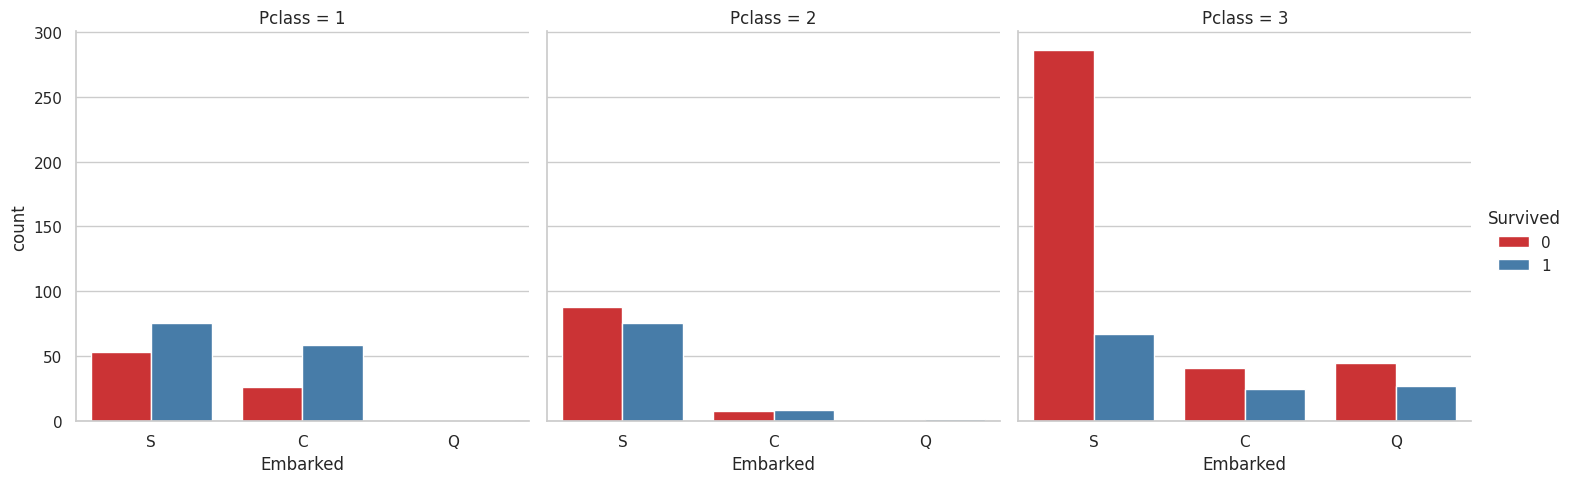

> Nhận xét 17: Dựa vào bảng số liệu và biểu đồ, ta thấy rõ ràng hành khách lên tàu từ cảng S ở hạng ghế Pclass 3 có số lượng thiệt mạng cao nhất (vượt trội hơn hẳn các nhóm còn lại). Trong khi đó, hành khách hạng 1 (Pclass 1) lên tàu tại cảng C có tỷ lệ sống sót rất tốt.


In [27]:
# 17. Số lượng người thiệt mạng và sống sót theo phân lớp (Pclass) và cảng cập bến (Embarked)
print("--- Bảng thống kê số lượng Sống/Chết theo Pclass và Embarked ---")
# Sử dụng train_df (hoặc df_all) tùy theo biến bạn đặt ở các bước trước
g_table = pd.crosstab([train_df['Pclass'], train_df['Embarked']], train_df['Survived'])
g_table.columns = ['Thiet_mang', 'Song_sot']
print(g_table)

print("\n--- Biểu đồ trực quan hóa ---")
# Vẽ đồ thị bằng catplot siêu an toàn và trực quan
sns.catplot(x='Embarked', hue='Survived', col='Pclass', data=train_df, kind='count', palette='Set1')
plt.show()

print(
    "> Nhận xét 17: Dựa vào bảng số liệu và biểu đồ, ta thấy rõ ràng hành khách lên tàu từ cảng S "
    "ở hạng ghế Pclass 3 có số lượng thiệt mạng cao nhất (vượt trội hơn hẳn các nhóm còn lại). "
    "Trong khi đó, hành khách hạng 1 (Pclass 1) lên tàu tại cảng C có tỷ lệ sống sót rất tốt."
)0